### Model inspired by:

- [1] Offshore Pipelaying Dynamics. Gullik Anthon Jensen
- [2] A nonlinear PDE formulation for offshore vessel pipeline installation. Gullik A. Jensen et al
- [3] Modeling and Control of Offshore Pipelay Operations Based on a Finite Strain Pipe Model. Gullik A. Jensen

### Implementation aspects:

- The model can be applied to normal dynamic pipelay condition as a rough estimate

In [1]:
import numpy as np
import inspect
import matplotlib.pyplot as plt
import scipy
from datetime import datetime
from scipy.optimize import root
from scipy.integrate import solve_ivp
from scipy import interpolate
import plotly.graph_objects as go
from scipy.interpolate import interp1d
from scipy import integrate
import scipy.sparse as sp
import scipy.sparse.linalg as spla

In [2]:
import diffeqpy
from diffeqpy import de
from juliacall import Main as jl

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


  Activating project at `~/.julia/environments/diffeqpy`


### Input data:

In [3]:
mp = 179.7      #  (submerged pipe weight) [kg/m]
N = 20    # number of modelling nodes

In [4]:
qw = 1025 # Water density [kg/m3]
d0 = 0.508 # Outer diameter of pipe, [m]
dI= (508-33*2)/1000 # Inner diameter of pipe, [m]

In [5]:
# Underwater current: 
dv1_curr = 0
dv2_curr = 0
dv3_curr = 0

In [6]:
Fx_0 = 1515*1000
Fy_0 = 0.8*Fx_0
LTD = 209

In [7]:
E = 207e9
G = 79.3e9
nu0 = 0.3

In [8]:
TPL =  LTD/(N-1)

In [9]:
# vessel

In [10]:
mn = 39_989_000 # mass of the vessel, [kg]
L = 168 
Xg = 78 # [m]
Yg = 10
Zg = 1

In [11]:
# Fossen book p.181
def vessel_inertia_moment(mn, Xg, L):
    r = 0.25*L
    Ir = mn*r**2
    Iz = mn*Xg**2 + Ir
    return Iz

In [12]:
In = vessel_inertia_moment(mn, Xg, L)

In [13]:
draft = 6

In [14]:
# integration parameters
tspan = (0.,2.)

In [15]:
A_wp = 6000

### Main functions:

In [16]:
A = np.pi * ((d0/2)**2 - (dI/2)**2)

In [17]:
m = (dI/2)/ (d0/2)
m2 = m**2
k_shear = (6.0 * (1.0 + nu0) * (1.0 + m2)**2) / (
    (7.0 + 6.0 * nu0) * (1.0 + m2)**2 + (20.0 + 12.0 * nu0) * m2)

In [18]:
A2 = k_shear * A
A3 = k_shear * A

In [19]:
J = (np.pi / 2.0) * ((d0/2)**4 - (dI/2)**4)

In [20]:
J1 = J

In [21]:
J2 = (np.pi / 64) * (d0**4 - dI**4)
J3 = J2

In [22]:
I1=(1/2)*mp*((d0/2)**2+(dI/2)**2)*TPL

In [23]:
I1

112.03639095

In [24]:
I2 = (1/12)*mp*(3*(d0/2)**2+3*(dI/2)**2)*TPL
I3 = I2

In [25]:
I3

56.01819547499999

In [26]:
def Πe(φ, θ, ψ):
    max_safe_angle = np.radians(89.9) 
    φ_clamped = np.clip(φ, -max_safe_angle, max_safe_angle)
    return np.array([
        [ np.cos(θ), 0, np.cos(φ_clamped) * np.sin(θ)], 
        [         0, 1, -np.sin(φ_clamped)], 
        [-np.sin(θ), 0, np.cos(φ_clamped) * np.cos(θ)]
    ])        

In [27]:
def Ret_e_t(φ, θ, ψ):
    safety_margin = 0.001 
    θ = np.clip(θ, -np.pi/2 + safety_margin, np.pi/2 - safety_margin)
    
    is_array = isinstance(φ, np.ndarray)
    N = len(φ) if is_array else 1

    cos_f, sin_f = np.cos(φ), np.sin(φ)
    cos_t, sin_t = np.cos(θ), np.sin(θ)
    cos_p, sin_p = np.cos(ψ), np.sin(ψ)

    if is_array:
        C = np.zeros((N, 3, 3))
    else:
        C = np.zeros((3, 3))

    C[..., 0, 0] = cos_t * cos_p + sin_t * sin_f * sin_p
    C[..., 0, 1] = -cos_t * sin_p + sin_t * sin_f * cos_p
    C[..., 0, 2] = sin_t * cos_f

    C[..., 1, 0] = cos_f * sin_p
    C[..., 1, 1] = cos_f * cos_p
    C[..., 1, 2] = -sin_f

    C[..., 2, 0] = -sin_t * cos_p + cos_t * sin_f * sin_p
    C[..., 2, 1] = sin_t * sin_p + cos_t * sin_f * cos_p
    C[..., 2, 2] = cos_t * cos_f

    return C

In [28]:
diag_J_t_rho = np.array([I1, I2, I3])      
J_t_rho = np.diag(diag_J_t_rho)

In [29]:
diag_CT = np.array([E*A, G*A2, G*A3])
CT=np.diag(diag_CT) 

In [30]:
diag_CR = np.array([G*J, E*J2, E*J3]) 
CR=np.diag(diag_CR) 

In [31]:
diag_DT = 1.5*np.array([1, 1, 1])
DT=np.diag(diag_DT)

In [32]:
diag_DR = 1.5*np.array([1, 1, 1])  
DR=np.diag(diag_DR)

In [33]:
def I_e_rho(φ,θ,ψ):
    return Ret_e_t(φ,θ,ψ) @ J_t_rho @ Ret_e_t(φ,θ,ψ).T

In [34]:
def phi(x,y,z): return np.array([x,y,z]) 
def theta(φ,θ,ψ): return np.array([φ,θ,ψ]) 

In [35]:
def d_s_theta(φ1,θ1,ψ1,φ2,θ2,ψ2,h):
    return 1/h*(theta(φ2,θ2,ψ2) - theta(φ1,θ1,ψ1))      

In [36]:
def S(a1, a2, a3 ):
    return np.array([[0, -a3, a2 ],
                         [a3, 0, -a1],
                        [-a2, a1, 0]])

In [37]:
def d_s_phi(x1,y1,z1,x2,y2,z2, h):
    return 1/h*(phi(x2,y2,z2)-phi(x1,y1,z1))

In [38]:
def ne(x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h):
    res = Ret_e_t(φ1,θ1,ψ1) @ CT @ Ret_e_t(φ1,θ1,ψ1).T @ (
        d_s_phi(x1,y1,z1,x2,y2,z2,h).flatten() 
        - Ret_e_t(φ1,θ1,ψ1) @ np.array([1,0,0])
    )
    return res.flatten()    

In [39]:
def me(φ1, θ1, ψ1, φ2, θ2, ψ2, h):
    kappa_e = Πe(φ1, θ1, ψ1) @ d_s_theta(φ1, θ1, ψ1, φ2, θ2, ψ2, h)
    return Ret_e_t(φ1, θ1, ψ1) @ CR @ kappa_e   

In [40]:
def dΠ(φ, θ, ψ, dφ, dθ, dψ):
    max_safe_angle = np.radians(89.9) 
    φ_clamped = np.clip(φ, -max_safe_angle, max_safe_angle)
    
    return np.array([
        [-np.sin(θ)*dθ, 0, -np.sin(φ_clamped)*dφ*np.sin(θ) + np.cos(φ_clamped)*np.cos(θ)*dθ],
        [            0, 0, -np.cos(φ_clamped)*dφ],
        [-np.cos(θ)*dθ, 0, -np.sin(φ_clamped)*dφ*np.cos(θ) - np.cos(φ_clamped)*np.sin(θ)*dθ]
    ])    

In [41]:
fe_g = np.array([0,0, mp*TPL*9.81])

In [42]:
# def f_t_d(dx,dy,dz): 
    
#     vr1 = dx - dv1_curr
#     vr2 = dy - dv2_curr  
#     vr3 = dz - dv3_curr
#     A = np.array([np.abs(vr1) * vr1,
#                   np.sqrt(vr2**2 + vr3**2) * vr2,
#                  np.sqrt(vr2**2 + vr3**2) * vr3])
#     return 0.5 * d0 * qw * (DT@ A)

def f_t_d(dx, dy, dz): 
    vr1 = dx - dv1_curr
    vr2 = dy - dv2_curr  
    vr3 = dz - dv3_curr
    
    v_cross_mag = np.sqrt(vr2**2 + vr3**2)
   
    if v_cross_mag > 1e-10:
        
        A = np.array([
            np.abs(vr1) * vr1,
            v_cross_mag * vr2,
            v_cross_mag * vr3
        ])
    else:
        A = np.array([np.abs(vr1) * vr1, 0.0, 0.0])
        
    return 0.5 * d0 * qw * (DT @ A)


In [43]:
def sigma(x,y,z):
    e3 = np.array([0,0,1])
    
    k = -(phi(x,y,z) @ e3)+d0/2
    
    fe_g2 = np.linalg.norm(fe_g, ord=2)
   
    if k<0:
        k0=0
    elif 0<=k<=d0/20:
        k0=(fe_g2*10*k**2)/((d0/8-d0/40)*(d0))
    else:
        k0=(fe_g2*(k-d0/40))/(d0/8-d0/40)
            
    result = - k0 * e3 
   
    return result  

In [44]:
def Hmtrx(r):
    r = np.asarray(r, dtype=float).flatten()
    H = np.eye(6)
    H[0:3, 3:6] = S(*r).T
    return H

In [45]:
def compute_damping(M_CG, G_CG, rCG, T_x, T_y, T_n):
 
    beta_z = 0.995      
    beta_phi = 0.995    
    beta_theta = 0.995
 
   
    zeta_z = np.sqrt(1 - beta_z ** 2)
    zeta_phi = np.sqrt(1 - beta_phi ** 2)
    zeta_theta = np.sqrt(1 - beta_theta ** 2)
 
    D_CG11 = M_CG[0, 0] / T_x
    D_CG22 = M_CG[1, 1] / T_y
    D_CG66 = M_CG[5, 5] / T_n
 
   
    k_z = G_CG[2, 2] if G_CG.ndim == 2 else G_CG[2]
    k_phi = G_CG[3, 3] if G_CG.ndim == 2 else G_CG[3]
    k_theta = G_CG[4, 4] if G_CG.ndim == 2 else G_CG[4]

    D_CG33 = 2 * zeta_z * np.sqrt(np.abs(M_CG[2, 2] * k_z))
    D_CG44 = 2 * zeta_phi * np.sqrt(np.abs(M_CG[3, 3] * k_phi))
    D_CG55 = 2 * zeta_theta * np.sqrt(np.abs(M_CG[4, 4] * k_theta))
 
    D_CG = np.diag([D_CG11, D_CG22, D_CG33, D_CG44, D_CG55, D_CG66])
 
    H = Hmtrx(rCG)
    D = H.T @ D_CG @ H
 
    return D

In [46]:
def compute_added_mass_placeholder(MRB_CG, rCG, ratios=None):
    """
    Reasonable stand-in for MA when you don't yet have geometry data to run
    `compute_added_mass`, but need a plausible, positive-definite MA to
    exercise the rest of the pipeline (M, G_CG, D, eigenvalues, periods).
 
    Rather than scaling the whole MRB matrix by one constant (e.g.
    MA = 0.5*MRB), this scales each diagonal DOF of MRB_CG by a *different*,
    physically motivated ratio, since added mass/inertia does not scale
    uniformly across DOFs. Typical literature ratios for semi-submersibles/
    ships (added mass or added inertia, as a fraction of rigid-body mass or
    inertia) are used as defaults:
 
        surge : 0.10   (slender-body, low added mass fore-aft)
        sway  : 0.80   (broadside added mass is large)
        heave : 1.20   (column-stabilized units: often exceeds rigid mass)
        roll  : 0.30   (added inertia, moderate)
        pitch : 0.90   (added inertia, large - long waterline)
        yaw   : 0.90   (added inertia, large)
 
    These are ROUGH DEFAULTS ONLY -- real added mass depends on hull/column/
    pontoon shape, submergence, and frequency, and should eventually be
    replaced by `compute_added_mass` once geometry data is available.
 
    Parameters
    ----------
    MRB_CG : (6, 6) ndarray
        Rigid-body mass matrix at CG (block-diagonal: m*I3, diag(Ix,Iy,Iz)).
    rCG : (3,) array_like
        Center of gravity with respect to CO (for the CG -> CO transform).
    ratios : (6,) array_like, optional
        Override the six default ratios above, in DOF order
        [surge, sway, heave, roll, pitch, yaw].
 
    Returns
    -------
    MA : (6, 6) ndarray
        Added mass matrix with respect to CO (diagonal at CG, transformed
        to CO -- no cross-coupling terms, unlike a geometry-derived MA).
    """
 
    if ratios is None:
        ratios = [0.10, 0.80, 1.20, 0.30, 0.90, 0.90]
 
    diag_CG = np.diag(MRB_CG)
    MA_CG = np.diag(diag_CG * np.asarray(ratios, dtype=float))
 
    # Transform from CG to CO -- same pattern used for MRB_CG -> MRB
    # elsewhere in this script: X_CO = Hmtrx(rCG).T @ X_CG @ Hmtrx(rCG)
    MA = Hmtrx(rCG).T @ MA_CG @ Hmtrx(rCG)
 
    return MA

In [47]:
def coriolis_matrix(M, nu):
    U = np.linalg.norm(nu)
    L = np.zeros((6, 6))
    L[1, 5] = 1.0  
    L[2, 4] = -1.0 
    C = M @ (U * L)
    return C

In [48]:
e1 = np.array([1.0, 0.0, 0.0])
e2 = np.array([0.0, 1.0, 0.0])
e3 = np.array([0.0, 0.0, 1.0])

In [49]:
class VesselRestoringParams:
    """
    Physical/geometric parameters needed for the restoring
    force/moment model, eqs. (57)-(63).
    """
    def __init__(self, A_wp, rho_w, g, z_eq, m_V, GM_L, GM_T):
        self.A_wp = A_wp      # water plane area [m^2]
        self.rho_w = rho_w    # water density [kg/m^3]
        self.g = g            # gravitational acceleration [m/s^2]
        self.z_eq = z_eq      # heave equilibrium position [m]
        self.m_V = m_V        # vessel mass [kg]
        self.GM_L = GM_L      # longitudinal metacentric height [m]
        self.GM_T = GM_T      # transversal metacentric height [m]

In [50]:
def heave_restoring_force(u_L, params: VesselRestoringParams):
    """
    g^e_l = -A_wp * rho_w * g * (u^T(L,t) e3 - z_eq) * e3

    Parameters
    ----------
    u_L : (3,) array
        Position of the pipe end attached to the vessel, u(L, t),
        expressed in the earth-fixed frame e.
    """
    heave = u_L @ e3
    g_e_l = -params.A_wp * params.rho_w * params.g * (heave - params.z_eq) * e3
    return g_e_l

In [51]:
def roll_pitch_sines(R_e_b):
    """
    sin(theta) and sin(phi) without explicit Euler angles, eqs. (59)-(60):
        sin(theta) = (R^e_b e1)^T e3
        sin(phi)  ~= (R^e_b e2)^T e3     (small-pitch approximation, cos(theta)=1)
    """
    sin_theta = (R_e_b @ e1) @ e3
    sin_phi = (R_e_b @ e2) @ e3
    return sin_phi, sin_theta

In [52]:
def moment_arm_body(R_e_b, params: VesselRestoringParams):
    """
    r~^b_r, eq. (61):
        r~^b_r = [ GM_L * (R^e_b e1)^T e3 ,
                   GM_T * (R^e_b e2)^T e3 ,
                   0 ]^T
    """
    sin_phi, sin_theta = roll_pitch_sines(R_e_b)
    r_tilde_b_r = np.array([
        -params.GM_L * sin_theta,
        -params.GM_T * sin_phi,
        0.0
    ])
    return r_tilde_b_r

In [53]:
def restoring_moment(R_e_b, params: VesselRestoringParams):
    """
    g^e_r = r~^e_r x f^e_r = (R^e_b r~^b_r) x (m_V g e3)
    """
    r_tilde_b_r = moment_arm_body(R_e_b, params)
    r_tilde_e_r = R_e_b @ r_tilde_b_r
    f_e_r = -params.m_V * params.g * e3
    g_e_r = np.cross(r_tilde_e_r, f_e_r)
    return g_e_r

In [54]:
def restoring_vector_body(u_L, R_e_b, params: VesselRestoringParams):
    """
    g^b(u(L,t), R^e_b(t)) =
        [ (R^e_b)^T g^e_t ]
        [ (R^e_b)^T g^e_r ]

    where g^e_t = g^e_l (only heave translational restoring, eq. 57)
    and   g^e_r is the restoring moment, eq. (62).

    Returns
    -------
    g_b : (6,) ndarray
        [Fx, Fy, Fz, Mx, My, Mz] restoring generalized force in body frame.
    """
    g_e_t = heave_restoring_force(u_L, params)      # translational restoring, e-frame
    g_e_r = restoring_moment(R_e_b, params)          # rotational restoring, e-frame

    g_b_t = R_e_b.T @ g_e_t
    g_b_r = R_e_b.T @ g_e_r

    g_b = np.concatenate([g_b_t, g_b_r])
    return g_b

In [55]:
class MyTime:
    def __init__(self):
        self.progression = [i for i in range(650)]
        self.wall_clock = datetime.now()
        self.top_tension = -float('inf')
        self.sagbend_strain = -float('inf')
        self.my_iter = 0
        
        self.r_g = np.array([Xg, Yg, Zg])
        self.r_b = np.array([0, 0, -draft/2])
        
        self.W = mn*9.81
        self.BO = self.W
        
        self.MRB = np.block([[mn*np.identity(3), np.zeros((3,3))], 
                             [np.zeros((3,3)), In*np.identity(3)]])
        
        self.MA = compute_added_mass_placeholder(self.MRB, self.r_g)
        
        self.M = self.MRB + self.MA

        self.CRB = coriolis_matrix
        
        self.CA = coriolis_matrix

### Static solution

In [56]:
def catenary(x,Ws,Fh):
    return (Fh/Ws)*(np.cosh(x*Ws/Fh)-1)

In [57]:
mi = [mp for i in range(N)]

In [58]:
pipe_weight_per_unit_length = mi #  (submerged) [kg/m]  # 113.07 - not submerged

In [59]:
Ws = np.array(pipe_weight_per_unit_length)*9.81 # [N/m]

In [60]:
horizontal_length=2*(Fx_0/Ws[0])*(np.sinh(LTD*Ws[0]/(2*Fx_0)))

In [61]:
delta_x=horizontal_length/(N-1)

In [62]:
x0=[i*delta_x for i in range(N)]
z0=[]

for i in range(len(x0)):
    z0.append(catenary(x0[i],Ws[0],Fx_0))

length_p=[]
for i in range(1,len(z0)):
    length_p.append(np.sqrt((x0[i]-x0[i-1])**2+(z0[i]-z0[i-1])**2))

In [63]:
cum_len = 0
length_p1=[0]
for i in range(len(length_p)):
    cum_len+=length_p[i]
    length_p1.append(cum_len)

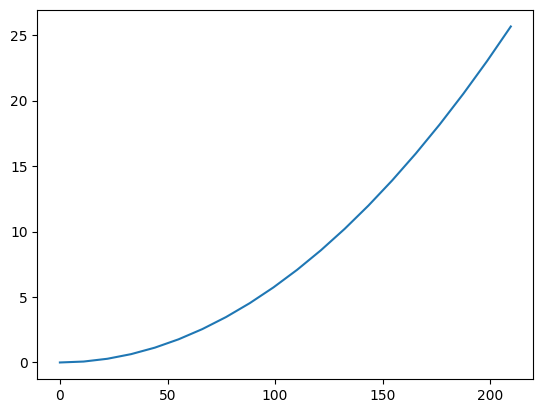

In [64]:
plt.plot(x0, z0)
plt.show()

In [65]:
q0=np.zeros(12*N)

In [66]:
for j in range(1,12):
    if j==1:
        q0[(j-1)*N:j*N]=x0
    elif j==5:
        q0[(j-1)*N:j*N]=z0

In [67]:
h = delta_x

In [68]:
def fun1(x_int,φ,θ,ψ,t):
    
    def fun1_(x_int,φ,θ,ψ,t):
        A=mp*TPL*1/2*(1-x_int)*1/2*(1+x_int)*np.identity(3)
        B=np.zeros((3,3))
     
        D=1/2*(1-x_int)*1/2*(1+x_int)*I_e_rho(φ,θ,ψ)@Πe(φ,θ,ψ)
            
        return h/2*np.block([[A, B], [B, D]])
    
    res = np.array([fun1_(xi,φ,θ,ψ,t) for xi in x_int])
    return np.moveaxis(res, 0, -1)


def fun2_1(x_int, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h):
    
    def fun2_1_(x_int, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h):
        A=1/h*np.identity(3)
        B=np.zeros((3,3))
        C=-1/2*(1+x_int)*S(*d_s_phi(x1, y1, z1, x2, y2, z2, h))
        return h/2*np.block([[A, B], [C, A]])@np.concatenate((np.asarray(ne(x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h)),
                                                              np.asarray(me(φ1, θ1, ψ1, φ2, θ2, ψ2, h))), axis=None)
    
    res = np.array([fun2_1_(xi, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h) for xi in x_int])
    return np.moveaxis(res, 0, -1)

    
def fun2_2(x_int, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h):
    
    def fun2_2_(x_int, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h):
        A=1/h*np.identity(3)
        B=np.zeros((3,3))
        C=-1/2*(1-x_int)*S(*d_s_phi(x1, y1, z1, x2, y2, z2, h))
        return h/2*np.block([[A, B], [C, A]])@np.concatenate((np.asarray(ne(x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h)),
                                                              np.asarray(me(φ1, θ1, ψ1, φ2, θ2, ψ2, h))), axis=None)
    
    res = np.array([fun2_2_(xi, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h) for xi in x_int])
    return np.moveaxis(res, 0, -1)    

    
def fun3_1(x_int,φ,θ,ψ, dφ, dθ, dψ,t):
    
    def fun3_1_(x_int,φ,θ,ψ, dφ, dθ, dψ,t):
        A=np.zeros(3)  
        B=1/2*(1+x_int)*I_e_rho(φ,θ,ψ)@dΠ(φ, θ, ψ, dφ, dθ, dψ)@np.array([dφ, dθ, dψ])
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun3_1_(xi,φ,θ,ψ, dφ, dθ, dψ,t) for xi in x_int])
    return np.moveaxis(res, 0, -1)  

    
def fun3_2(x_int,φ,θ,ψ, dφ, dθ, dψ,t):
    
    def fun3_2_(x_int,φ,θ,ψ, dφ, dθ, dψ,t):
        A=np.zeros(3) 
        B=1/2*(1-x_int)*I_e_rho(φ,θ,ψ)@dΠ(φ, θ, ψ, dφ, dθ, dψ)@np.array([dφ, dθ, dψ])
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun3_2_(xi,φ,θ,ψ, dφ, dθ, dψ,t) for xi in x_int])
    return np.moveaxis(res, 0, -1)    

    
def fun4_1(x_int,φ,θ,ψ, dφ, dθ, dψ,t):
    
    def fun4_1_(x_int,φ,θ,ψ, dφ, dθ, dψ,t):
        A=np.zeros(3)  
        B=1/2*(1+x_int)*S(*(Πe(φ, θ, ψ)@np.array([dφ, dθ, dψ])))@(I_e_rho(φ,θ,ψ)@Πe(φ, θ, ψ)@np.array([dφ, dθ, dψ])).T
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun4_1_(xi,φ,θ,ψ, dφ, dθ, dψ,t) for xi in x_int])
    return np.moveaxis(res, 0, -1)

    
def fun4_2(x_int,φ,θ,ψ, dφ, dθ, dψ,t):
    
    def fun4_2_(x_int,φ,θ,ψ, dφ, dθ, dψ,t):
        A=np.zeros(3) 
        B=1/2*(1-x_int)*S(*(Πe(φ, θ, ψ)@np.array([dφ, dθ, dψ])))@(I_e_rho(φ,θ,ψ)@Πe(φ, θ, ψ)@np.array([dφ, dθ, dψ])).T
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun4_2_(xi,φ,θ,ψ, dφ, dθ, dψ,t) for xi in x_int])
    return np.moveaxis(res, 0, -1)    

    
def fun5_1(x_int, li):
    
    def fun5_1_(x_int, li):
        B=np.zeros(3)   
        A=1/2*(1+x_int)*fe_g*li
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun5_1_(x, li) for x in x_int])
    return np.moveaxis(res, 0, -1)

    
def fun5_2(x_int, li):
    
    def fun5_2_(x_int, li):
        B=np.zeros(3)   
        A=1/2*(1-x_int)*fe_g*li
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun5_2_(x, li) for x in x_int])
    return np.moveaxis(res, 0, -1)    

    
def fun6_1(x_int,φ,θ,ψ, dx, dy, dz, dφ, dθ, dψ):
    
    def fun6_1_(x_int,φ,θ,ψ, dx, dy, dz, dφ, dθ, dψ):
        A=1/2*(1+x_int)* Ret_e_t(φ,θ,ψ)@f_t_d(dx,dy,dz)
        B=1/2*(1+x_int)* DR@ Πe(φ, θ, ψ)@  np.array([dφ, dθ, dψ])

        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)  
    
    res = np.array([fun6_1_(xi,φ,θ,ψ, dx, dy, dz, dφ, dθ, dψ) for xi in x_int])
    return np.moveaxis(res, 0, -1)


def fun6_2(x_int,φ,θ,ψ, dx, dy, dz, dφ, dθ, dψ):
    
    def fun6_2_(x_int,φ,θ,ψ, dx, dy, dz, dφ, dθ, dψ):
        A=1/2*(1-x_int)* Ret_e_t(φ,θ,ψ)@f_t_d(dx,dy,dz)
        B=1/2*(1-x_int)* DR@ Πe(φ, θ, ψ)@  np.array([dφ, dθ, dψ])

        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun6_2_(xi,φ,θ,ψ, dx, dy, dz, dφ, dθ, dψ) for xi in x_int])
    return np.moveaxis(res, 0, -1)    

    
def fun7_1(x_int,x,y,z):
   
    def fun7_1_(x_int,x,y,z):
        A=1/2*(1+x_int)*sigma(x,y,z)
        B=np.zeros(3) 

        ans=h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)

        return ans
    
    res = np.array([fun7_1_(xi,x,y,z) for xi in x_int])
    return np.moveaxis(res, 0, -1)


def fun7_2(x_int,x,y,z):
   
    def fun7_2_(x_int,x,y,z):
        A=1/2*(1-x_int)*sigma(x,y,z)
        B=np.zeros(3) 

        ans=h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)

        return ans
    
    res = np.array([fun7_2_(xi,x,y,z) for xi in x_int])
    return np.moveaxis(res, 0, -1)    

In [69]:
def body_frame_nu(u_dot_xyz, phi, theta, psi, dphi, dtheta, dpsi):
    """Eq. (64): rotate spatial velocity + convert Euler rates -> body-frame nu."""
    Re_b = Ret_e_t(phi, theta, psi)
    w_e  = Πe(phi, theta, psi) @ np.array([dphi, dtheta, dpsi])   # Eq. (100)
    nu_lin = Re_b.T @ np.asarray(u_dot_xyz)
    nu_ang = Re_b.T @ w_e
    return np.concatenate([nu_lin, nu_ang])

In [70]:
def static_solution(Q,T): 
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    f1=[]
    f2=[]
    f3=[] 
    f4=[]
    f5=[]
    f6=[]
    f7=[]
    f8=[]
   
    for j in range(1, N):
        
        if j == N-1:
            g_eta = restoring_vector_body(phi(x[j],y[j],z[j]), Ret_e_t(φ[j], θ[j], ψ[j]), 
                                      VesselRestoringParams(
                                                            A_wp = A_wp,     # m^2, water plane area
                                                            rho_w = qw,    # kg/m^3
                                                            g = 9.81,       # m/s^2
                                                            z_eq = z0[-1],  # equilibrium heave [m]
                                                            m_V = mn,       # kg, vessel mass
                                                            GM_L = L,       # m, longitudinal metacentric height
                                                            GM_T = 2*Yg,        # m, transversal metacentric height
                                                        ))
            
            f1.append(integrate.fixed_quad(lambda x_int: fun1(x_int, φ[j], θ[j], ψ[j],0), -1.0, 1.0, n=2)[0])
            f2.append(integrate.fixed_quad(lambda x_int: fun2_1(x_int, x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],φ[j],θ[j],ψ[j],h), -1.0,1.0,n=1)[0])
            f3.append(integrate.fixed_quad(lambda x_int: fun3_1(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j],0), -1.0, 1.0, n=2)[0])
            f4.append(integrate.fixed_quad(lambda x_int: fun4_1(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j],0), -1.0, 1.0, n=2)[0])
            f5.append(integrate.fixed_quad(lambda x_int: fun5_1(x_int, 1), -1.0, 1.0, n=2)[0])
            f6.append(integrate.fixed_quad(lambda x_int: fun6_1(x_int, φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j]), -1.0, 1.0, n=2)[0])
            f7.append(integrate.fixed_quad(lambda x_int: fun7_1(x_int, x[j],y[j],z[j]), -1.0, 1.0, n=2)[0])
            f8.append(g_eta-np.array([Fx_0,0,0,0,0,0]))
        else:
            f1.append(integrate.fixed_quad(lambda x_int: fun1(x_int, φ[j], θ[j], ψ[j],0), -1.0, 1.0, n=2)[0])
            f2.append(integrate.fixed_quad(lambda x_int: fun2_1(x_int, x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],φ[j],θ[j],ψ[j],h), -1.0,1.0,n=1)[0]
                     +integrate.fixed_quad(lambda x_int: fun2_2(x_int, x[j],y[j],z[j],φ[j],θ[j],ψ[j],x[j+1],y[j+1],z[j+1],φ[j+1],θ[j+1],ψ[j+1],h), -1.0,1.0,n=1)[0])
            f3.append(integrate.fixed_quad(lambda x_int: fun3_1(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j],0), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun3_2(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j],0), -1.0, 1.0, n=2)[0])
            f4.append(integrate.fixed_quad(lambda x_int: fun4_1(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j],0), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun4_2(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j],0), -1.0, 1.0, n=2)[0])
            f5.append(integrate.fixed_quad(lambda x_int: fun5_1(x_int, 1), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun5_2(x_int, 1), -1.0, 1.0, n=2)[0])
            f6.append(integrate.fixed_quad(lambda x_int: fun6_1(x_int, φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j]), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun6_2(x_int, φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j]), -1.0, 1.0, n=2)[0])
            f7.append(integrate.fixed_quad(lambda x_int: fun7_1(x_int, x[j],y[j],z[j]), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun7_2(x_int, x[j],y[j],z[j]), -1.0, 1.0, n=2)[0])
            f8.append(np.zeros(6))

    f1 = np.array(f1)
    f1 = np.stack(f1, axis=0)
    f2=np.vstack(f2) 
    f3=np.vstack(f3)
    f4=np.vstack(f4) 
    f5=np.vstack(f5)
    f6=np.vstack(f6) 
    f7=np.vstack(f7) 
    f8=np.vstack(f8)
    
    ddx=np.zeros(N)
    ddy=np.zeros(N)
    ddz=np.zeros(N)
    ddφ=np.zeros(N)
    ddθ=np.zeros(N)
    ddψ=np.zeros(N)
    
    f_sum = -(f2 + f3 + f4 + f5 + f6 + f8) 
    X = np.linalg.solve(f1, f_sum).reshape(N-1, 6)

    
    ddx0, ddy0, ddz0, ddφ0, ddθ0, ddψ0 = X.T  

    ddx[1:], ddy[1:], ddz[1:], ddφ[1:], ddθ[1:], ddψ[1:] = ddx0, ddy0, ddz0, ddφ0, ddθ0, ddψ0
      
    ans=np.concatenate([dx, ddx, 
                        dy, ddy,  
                        dz, ddz, 
                        dφ, ddφ,  
                        dθ, ddθ, 
                        dψ, ddψ,  
                       ], axis=0)
    return ans

In [71]:
T_1 = MyTime()

In [72]:
root_ = root(static_solution, q0, 
             # method='lm', 
             args=(T_1,))

In [73]:
root_

 message: The iteration is not making good progress, as measured by the 
            improvement from the last ten iterations.
 success: False
  status: 5
     fun: [-6.220e-07  1.088e-06 ...  7.270e-02  1.253e-02]
       x: [ 1.673e+04  1.674e+04 ...  0.000e+00  0.000e+00]
  method: hybr
    nfev: 492
    fjac: [[-1.823e-17  1.055e-17 ...  8.398e-02  1.772e-02]
           [ 1.774e-18 -4.103e-18 ... -9.850e-03 -3.306e-03]
           ...
           [ 3.374e-30 -7.256e-31 ... -2.487e-29 -1.183e-29]
           [-4.208e-31  9.175e-32 ...  3.480e-30  1.067e-30]]
       r: [ 2.872e+06  1.971e+07 ... -3.142e-01  4.882e-01]
     qtf: [-6.593e+06  5.958e+05 ...  6.256e-20 -8.675e-21]

In [74]:
x0_, y0_, z0_ = root_.x[:N],root_.x[2*N:3*N], root_.x[4*N:5*N]

In [75]:
x0_ -= x0_[0]
y0_ -= y0_[0]

In [76]:
# q0 = root_.x                                         # start from static solution

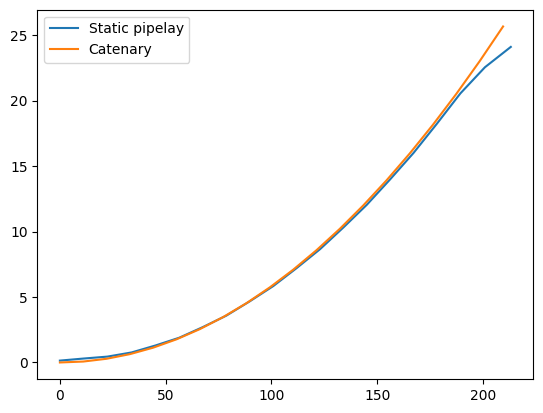

In [77]:
plt.plot(x0_, z0_, label = "Static pipelay")
plt.plot(x0, z0, label = "Catenary")
plt.legend()
plt.show()

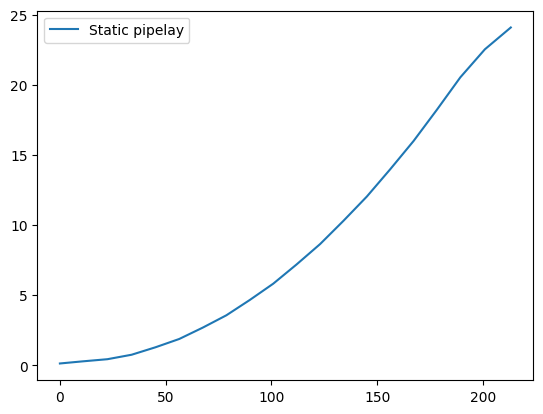

In [78]:
plt.plot(x0_, z0_, label = "Static pipelay")
plt.legend()
plt.show()

### Dynamic Simulation

In [79]:
def dynamic_func(du, Q, T, t):
        
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
        
    f1=[]
    f2=[]
    f3=[] 
    f4=[]
    f5=[]
    f6=[]
    f7=[]
    f8=[]
    
    for j in range(1,N):
        
        if j == N-1:
            nu = body_frame_nu(np.array([dx[j], dy[j], dz[j]]), φ[j], θ[j], ψ[j], dφ[j], dθ[j], dψ[j])
            C_nu = T.CRB(T.MRB, nu) + T.CA(T.MA, nu)
            g_eta = restoring_vector_body(phi(x[j],y[j],z[j]), Ret_e_t(φ[j], θ[j], ψ[j]), 
                                  VesselRestoringParams(
                                                        A_wp = A_wp,     # m^2, water plane area
                                                        rho_w = qw,    # kg/m^3
                                                        g = 9.81,       # m/s^2
                                                        z_eq = z0[-1],        # equilibrium heave [m]
                                                        # z_eq = z0_[-1],        #                            UNCOMMENT !!!
                                                        m_V = mn,       # kg, vessel mass
                                                        GM_L = L,       # m, longitudinal metacentric height
                                                        GM_T = 2*Yg,        # m, transversal metacentric height
                                                    ))
    
            D_nu = compute_damping(T.MRB, g_eta, T.r_g, 20, 100, 50)
    
            for_nu = np.block([[Ret_e_t(φ[j],θ[j],ψ[j]),  np.zeros((3,3))], 
                             [np.zeros((3,3)),  Ret_e_t(φ[j],θ[j],ψ[j]) @ Πe(φ[j],θ[j],ψ[j])]])
    
            
            f1.append(integrate.fixed_quad(lambda x_int: fun1(x_int, φ[j], θ[j], ψ[j],t), -1.0, 1.0, n=2)[0] + T.M @ for_nu)
            f2.append(integrate.fixed_quad(lambda x_int: fun2_1(x_int, x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],φ[j],θ[j],ψ[j],h), -1.0,1.0,n=1)[0])
            f3.append(integrate.fixed_quad(lambda x_int: fun3_1(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j],t), -1.0, 1.0, n=2)[0])
            f4.append(integrate.fixed_quad(lambda x_int: fun4_1(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j],t), -1.0, 1.0, n=2)[0])
            f5.append(integrate.fixed_quad(lambda x_int: fun5_1(x_int, 1), -1.0, 1.0, n=2)[0])
            f6.append((integrate.fixed_quad(lambda x_int: fun6_1(x_int, φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j]), -1.0, 1.0, n=2)[0]))
            f7.append(integrate.fixed_quad(lambda x_int: fun7_1(x_int, x[j],y[j],z[j]), -1.0, 1.0, n=2)[0])
            f8.append(g_eta  + (C_nu + D_nu) @ nu-np.array([Fx_0,0,0,0,0,0]))
        else:
            f1.append(integrate.fixed_quad(lambda x_int: fun1(x_int, φ[j], θ[j], ψ[j],t), -1.0, 1.0, n=2)[0])
            f2.append(integrate.fixed_quad(lambda x_int: fun2_1(x_int, x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],φ[j],θ[j],ψ[j],h), -1.0,1.0,n=1)[0]
                     +integrate.fixed_quad(lambda x_int: fun2_2(x_int, x[j],y[j],z[j],φ[j],θ[j],ψ[j],x[j+1],y[j+1],z[j+1],φ[j+1],θ[j+1],ψ[j+1],h), -1.0,1.0,n=1)[0])
            f3.append(integrate.fixed_quad(lambda x_int: fun3_1(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j],t), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun3_2(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j],t), -1.0, 1.0, n=2)[0])
            f4.append(integrate.fixed_quad(lambda x_int: fun4_1(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j],t), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun4_2(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j],t), -1.0, 1.0, n=2)[0])
            f5.append(integrate.fixed_quad(lambda x_int: fun5_1(x_int, 1), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun5_2(x_int, 1), -1.0, 1.0, n=2)[0])
            f6.append(integrate.fixed_quad(lambda x_int: fun6_1(x_int, φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j]), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun6_2(x_int, φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j]), -1.0, 1.0, n=2)[0])
            f7.append(integrate.fixed_quad(lambda x_int: fun7_1(x_int, x[j],y[j],z[j]), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun7_2(x_int, x[j],y[j],z[j]), -1.0, 1.0, n=2)[0])
            f8.append(np.zeros(6))
         
        if t>0.01 and j>0:
            ax=np.linalg.inv(Ret_e_t(φ[j],θ[j],ψ[j]))@ ne(x[j-1], y[j-1], z[j-1], φ[j-1], θ[j-1], ψ[j-1],x[j], y[j], z[j], φ[j], θ[j], ψ[j],h).T

            T.top_tension=max(T.top_tension, ax[0])            

            ben0=np.linalg.inv(Ret_e_t(φ[j],θ[j],ψ[j])) @ me( φ[j-1], θ[j-1], ψ[j-1], φ[j],θ[j],ψ[j],h).T
            ben=np.max(ben0[1:])

            I=3.14*(d0**4-dI**4)/64
            strain=np.max(ben)*d0/(2*E*I)    

            T.sagbend_strain=max(T.sagbend_strain, strain)    
    

    f1 = np.array(f1)
    f1 = np.stack(f1, axis=0)
    f2=np.vstack(f2) 
    f3=np.vstack(f3)
    f4=np.vstack(f4) 
    f5=np.vstack(f5)
    f6=np.vstack(f6) 
    f7=np.vstack(f7)
    f8=np.vstack(f8)
    
    ddx=np.zeros(N)
    ddy=np.zeros(N)
    ddz=np.zeros(N)
    ddφ=np.zeros(N)
    ddθ=np.zeros(N)
    ddψ=np.zeros(N)
  
    f_sum = -(f2 + f3 + f4 + f5 + f6 + f8)
    R_64 = f_sum.astype(np.float64, copy=False).flatten()
    
    beta_rayleigh = 1e-4
    if hasattr(T, 'last_X') and T.last_X is not None:
        R_64 -= beta_rayleigh * T.last_X.flatten()
    
    f1_64 = [block.astype(np.float64, copy=False) for block in f1]
    M_sparse = sp.block_diag(f1_64, format='csc')
    
    max_mass = np.max(np.abs(M_sparse.data)) 
    M_sparse = M_sparse + sp.diags([max_mass * 1e-4], [0], shape=M_sparse.shape, format='csc')
    
    solve_sparse = spla.splu(M_sparse).solve
    X_raw = solve_sparse(R_64)
    
    X = X_raw.reshape(N - 1, 6)

    ddx0, ddy0, ddz0, ddφ0, ddθ0, ddψ0 = X.T  

    ddx[1:], ddy[1:], ddz[1:], ddφ[1:], ddθ[1:], ddψ[1:] = ddx0, ddy0, ddz0, ddφ0, ddθ0, ddψ0

    ans=np.concatenate([dx, ddx, 
                        dy, ddy,  
                        dz, ddz, 
                        dφ, ddφ,  
                        dθ, ddθ, 
                        dψ, ddψ,  
                       ], axis=0)


        
    if t>T.progression[0]:
        
        T.progression.pop(0)
        print('Physical time: ', t, ' Iteration wall-clock time: ', datetime.now() - T.wall_clock , flush=True)
        T.wall_clock = datetime.now() 
    
    T.my_iter+=1 

    if np.any(np.abs(ans) > 1e10) or np.any(np.isnan(ans)):
        print(f"\n!!! CRITICAL SYSTEM EXPLOSION AT t = {t} !!!")
        
        bad_idx = np.where((np.abs(ans) > 1e10) | (np.isnan(ans)))[0]
        for idx in bad_idx:
            print(f"Index Q[{idx}] returned an invalid value: {ans[idx]}")
               
        print("Right-hand side vector R (first 20 elements):", f_sum[:20])
        print("Condition number of mass matrix M:", np.linalg.cond(M_64))
        
        raise ValueError("Simulation aborted due to Inf/NaN generation.")

    du[:] = ans 
    return None

In [80]:
def find_static_equilibrium(q0_guess, T, N, NDOF):
  
    x_init = q0_guess[0*N : 1*N]
    y_init = q0_guess[2*N : 3*N]
    z_init = q0_guess[4*N : 5*N]
    φ_init = q0_guess[6*N : 7*N]
    θ_init = q0_guess[8*N : 9*N]
    ψ_init = q0_guess[10*N : 11*N]
    
    geom_guess = np.concatenate([x_init, y_init, z_init, φ_init, θ_init, ψ_init])
    
    def static_residuals(geom_vector):
        x = geom_vector[0*N : 1*N]
        y = geom_vector[1*N : 2*N]
        z = geom_vector[2*N : 3*N]
        φ = geom_vector[3*N : 4*N]
        θ = geom_vector[4*N : 5*N]
        ψ = geom_vector[5*N : 6*N]
        
        v_zeros = np.zeros(N)
          
        Q_test = np.concatenate([
            x, v_zeros,        # 0*N : 2*N
            y, v_zeros,        # 2*N : 4*N
            z, v_zeros,        # 4*N : 6*N
            φ, v_zeros,        # 6*N : 8*N
            θ, v_zeros,        # 8*N : 10*N
            ψ, v_zeros,        # 10*N : 12*N
        ])
        
        du_output = np.zeros_like(Q_test)
        dynamic_func(du_output, Q_test, T, 0.0)
        
        ddx = du_output[1*N : 2*N]
        ddy = du_output[3*N : 4*N]
        ddz = du_output[5*N : 6*N]
        ddφ = du_output[7*N : 8*N]
        ddθ = du_output[9*N : 10*N]
        ddψ = du_output[11*N : 12*N]
        

        residuals = np.concatenate([
            ddx[1:], ddy[1:], ddz[1:],
            ddφ[1:], ddθ[1:], ddψ[1:]
        ])
        
       
        fix_residuals = np.array([x[0]-x_init[0], y[0]-y_init[0], z[0]-z_init[0], 
                                  φ[0]-φ_init[0], θ[0]-θ_init[0], ψ[0]-ψ_init[0]])
        
        return np.concatenate([fix_residuals, residuals])

    print("Launching static equilibrium calculation...")
    result = root(static_residuals, geom_guess, method='lm', tol=1e-5)
    
    if not result.success:
        print("WARNING: Static solution failed to converge! Message:", result.message)
    else:
        print("Static equilibrium successfully found!")

        
    geom_opt = result.x
    x_opt = geom_opt[0*N : 1*N]
    y_opt = geom_opt[1*N : 2*N]
    z_opt = geom_opt[2*N : 3*N]
    φ_opt = geom_opt[3*N : 4*N]
    θ_opt = geom_opt[4*N : 5*N]
    ψ_opt = geom_opt[5*N : 6*N]
    
    v_zeros = np.zeros(N) 
    Q0_perfect = np.concatenate([
        x_opt, v_zeros, y_opt, v_zeros, z_opt, v_zeros,
        φ_opt, v_zeros, θ_opt, v_zeros, ψ_opt, v_zeros
    ])
    
    return Q0_perfect

In [81]:
NA = N-1
DOF_PER_NODE = 6
NDOF = DOF_PER_NODE*NA

In [82]:
# T_2 = MyTime()

In [83]:
# Q0_balanced = find_static_equilibrium(q0, T_2, N, NDOF)

In [84]:
# x0_1, y0_1, z0_1 = Q0_balanced[:N], Q0_balanced[2*N:3*N], Q0_balanced[4*N:5*N]

In [85]:
# plt.plot(x0_1, z0_1, label = "Static pipelay")
# plt.plot(x0, z0, label = "Catenary")
# plt.legend()
# plt.show()

In [86]:
T_3 = MyTime()

In [87]:
startTime1 = datetime.now()

jl.seval("""
using Pkg
Pkg.add("OrdinaryDiffEqSDIRK")
using DifferentialEquations
using OrdinaryDiffEqSDIRK
""")

de = jl.seval("DifferentialEquations")
sdirk = jl.seval("OrdinaryDiffEqSDIRK")

# Problem
prob = de.ODEProblem(
    dynamic_func,
    q0,
    tspan,
    jl.Py(T_3)
)

sol = de.solve(
    prob,
    de.Rosenbrock23(autodiff=de.AutoFiniteDiff()),
    reltol=1e-6,
    abstol=1e-6
)
print(datetime.now() - startTime1)

   Resolving package versions...
  No Changes to `~/.julia/environments/diffeqpy/Project.toml`
  No Changes to `~/.julia/environments/diffeqpy/Manifest.toml`


Physical time:  0.0003534339477449774  Iteration wall-clock time:  0:00:12.809522
Physical time:  1.0007475085710977  Iteration wall-clock time:  0:40:02.579518
2:29:59.838831


### Results

In [89]:
# number of iterations
T_3.my_iter

376078

In [90]:
# max axial tension
T_3.top_tension

13063387825.950632

In [91]:
# max bending strain
T_3.sagbend_strain

1.5884226231445817

In [92]:
t = np.array(sol.t)
u = np.array(sol.u)

In [93]:
u_ = [list(vec) for vec in u.tolist()]

In [94]:
fin=np.array(u_)

In [95]:
t.shape, fin.shape

((1355,), (1355, 240))

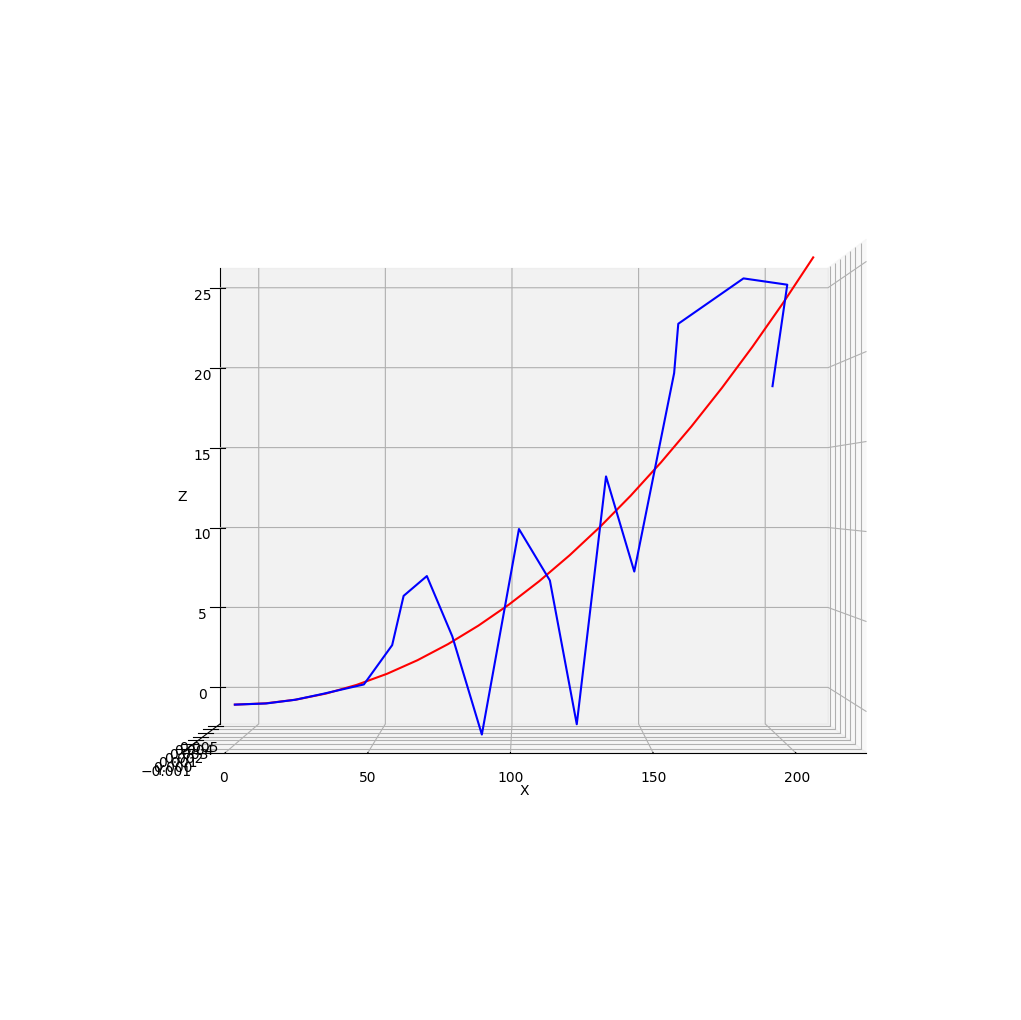

In [96]:
fig=plt.figure(figsize=(13,13))
ax = fig.add_subplot(projection = '3d')

X0=fin[0,[i for i in range(0,N)]]
Y0=fin[0,[i for i in range(2*N,3*N)]]
Z0=fin[0,[i for i in range(4*N,5*N)]]

j=-1
X=fin[j,[i for i in range(0,N)]]
Y=fin[j,[i for i in range(2*N,3*N)]]
Z=fin[j,[i for i in range(4*N,5*N)]]

num_true_pts = 200
tck, u = interpolate.splprep([X,Y,Z], s=2)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.plot(X0,Y0,Z0, color='r')
ax.plot(X,Y,Z, color='b')
ax.view_init(0,-90)
plt.show()

In [97]:
X,Y,Z

(array([  0.        ,  11.40244149,  21.82262243,  31.47932613,
         46.74589895,  56.98962421,  61.13769845,  69.55664284,
         78.78450269,  89.47708329, 102.92113919, 114.12055505,
        123.86406116, 134.461672  , 144.69892629, 159.13756598,
        160.85129656, 183.81545967, 197.77114968, 202.17615039]),
 array([ 0.00000000e+00, -8.94451801e-35,  2.10182624e-32, -4.95843865e-30,
         8.72967343e-28, -1.95547541e-25,  1.52624660e-23, -1.23518953e-21,
         7.69921195e-20, -4.75086227e-18,  3.81805022e-16, -4.25808118e-14,
         5.36153037e-12, -6.42876032e-10,  5.47179159e-08, -2.76364347e-06,
         2.34312699e-04, -3.38159695e-04, -1.50304593e-03,  5.01707856e-03]),
 array([ 0.        ,  0.06696654,  0.27769438,  0.60241986,  1.15765708,
         3.41297165,  6.24075393,  7.3775869 ,  3.91447044, -1.71762667,
        10.07765493,  7.12608475, -1.12678564, 13.09694673,  7.6369039 ,
        19.0295827 , 21.89478599, 24.39155632, 23.79977983, 18.79404908]))

In [98]:
X0,Y0,Z0

(array([  0.        ,  11.02712714,  22.05425428,  33.08138141,
         44.10850855,  55.13563569,  66.16276283,  77.18988997,
         88.21701711,  99.24414424, 110.27127138, 121.29839852,
        132.32552566, 143.3526528 , 154.37977994, 165.40690707,
        176.43403421, 187.46116135, 198.48828849, 209.51541563]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.]),
 array([ 0.        ,  0.07074654,  0.28299779,  0.63678871,  1.13217754,
         1.76924585,  2.54809852,  3.46886379,  4.53169324,  5.73676187,
         7.08426809,  8.57443374, 10.20750417, 11.98374825, 13.90345843,
        15.96695076, 18.17456499, 20.52666459, 23.02363679, 25.66589272]))

In [99]:
us=fin.T

In [100]:
us.shape

(240, 1355)

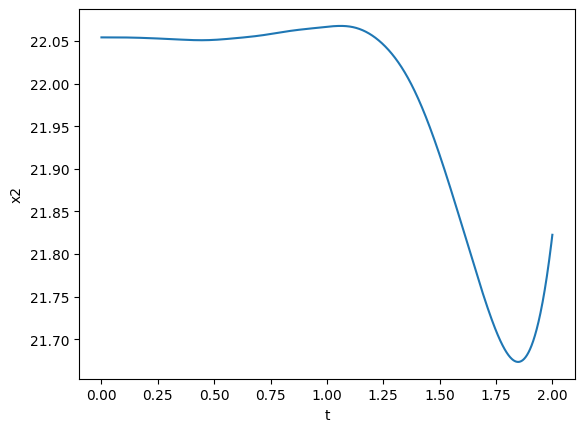

In [101]:
plt.plot(t,us.T[:,2],'-')
plt.xlabel('t')
plt.ylabel('x2')
plt.show()

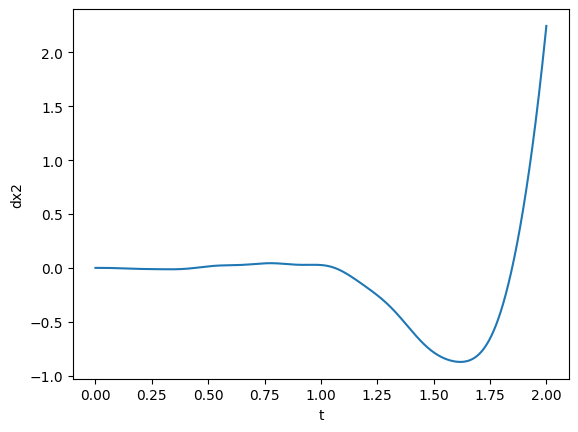

In [102]:
plt.plot(t,us.T[:,N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dx2')
plt.show()

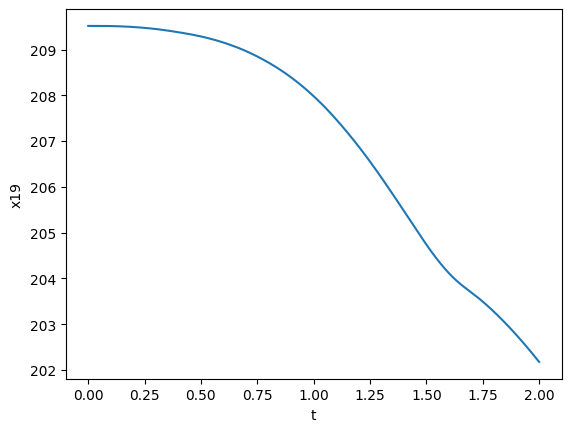

In [103]:
plt.plot(t,us.T[:,N-1] ,'-')
plt.xlabel('t')
plt.ylabel('x{}'.format(N-1))
plt.show()

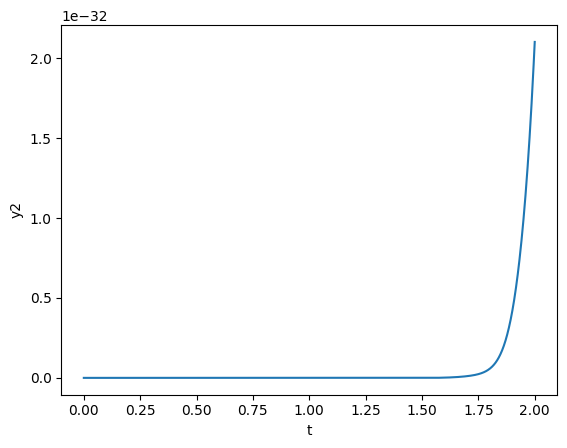

In [104]:
plt.plot(t,us.T[:,2*N +2] ,'-')
plt.xlabel('t')
plt.ylabel('y2')
plt.show()

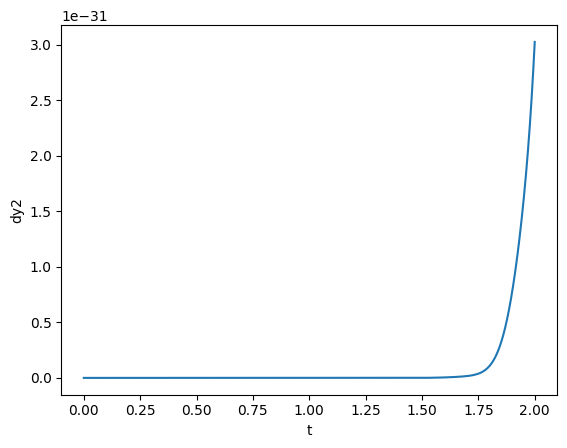

In [105]:
plt.plot(t,us.T[:,3*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dy2')
plt.show()

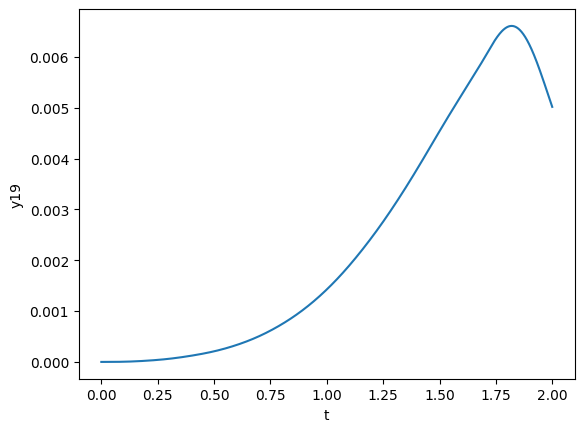

In [106]:
plt.plot(t,us.T[:,2*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('y{}'.format(N-1))
plt.show()

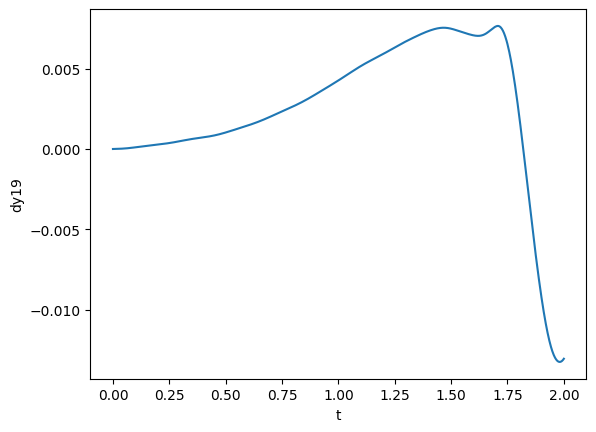

In [107]:
plt.plot(t,us.T[:,3*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('dy{}'.format(N-1))
plt.show()

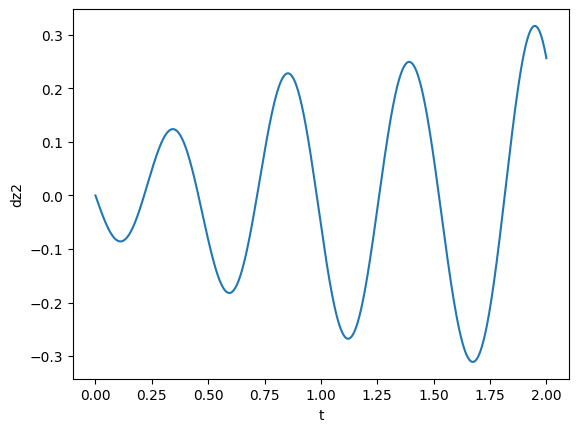

In [108]:
plt.plot(t,us.T[:,5*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dz2')
plt.show()

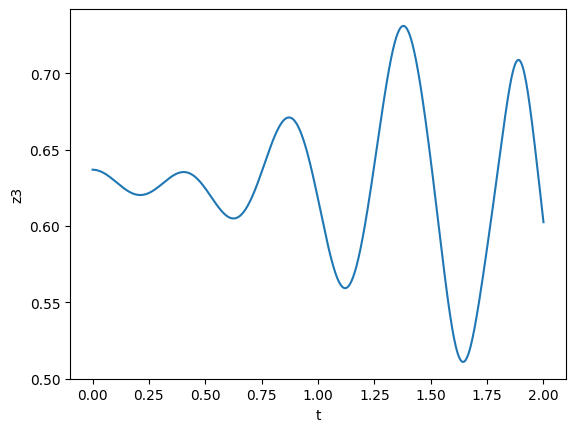

In [109]:
plt.plot(t,us.T[:,4*N+3] ,'-')
plt.xlabel('t')
plt.ylabel('z3')
plt.show()

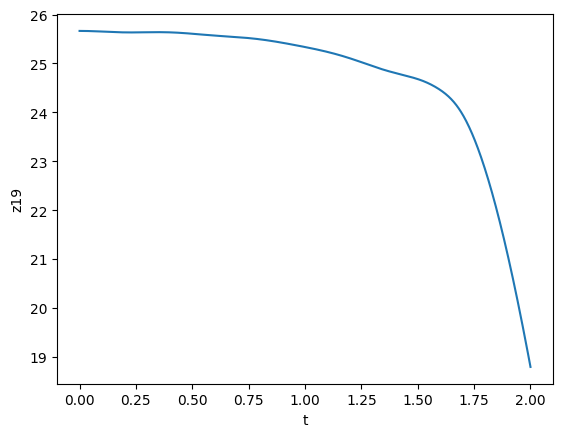

In [110]:
plt.plot(t,us.T[:,4*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('z{}'.format(N-1))
plt.show()

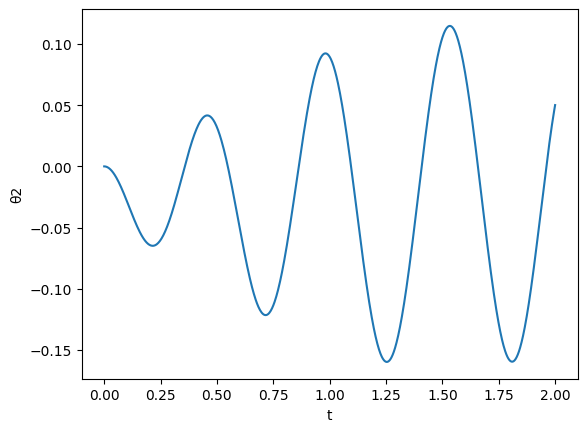

In [111]:
plt.plot(t,us.T[:,8*N+2],'-')
plt.xlabel('t')
plt.ylabel('θ2')
plt.show()

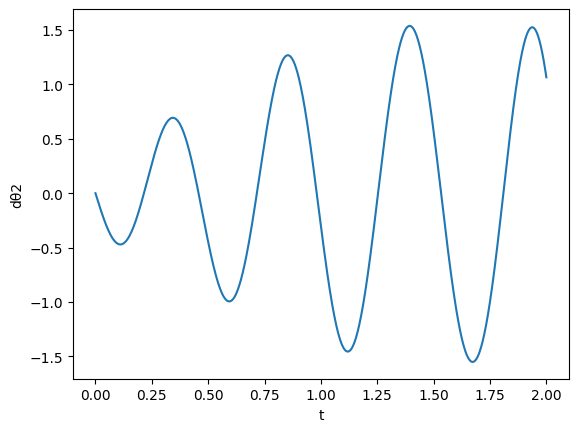

In [112]:
plt.plot(t,us.T[:,9*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dθ2')
plt.show()

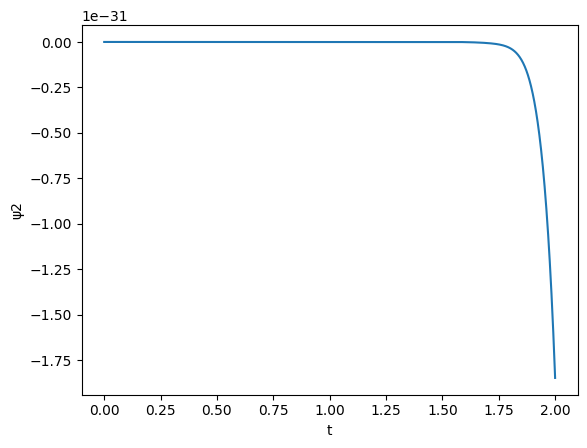

In [113]:
plt.plot(t,us.T[:,10*N+2],'-')
plt.xlabel('t')
plt.ylabel('ψ2')
plt.show()

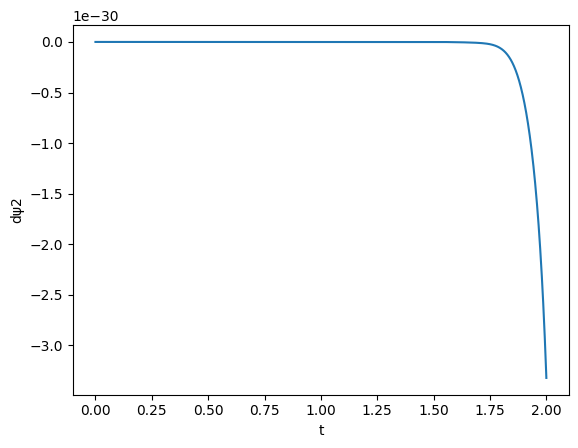

In [114]:
plt.plot(t,us.T[:,11*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dψ2')
plt.show()

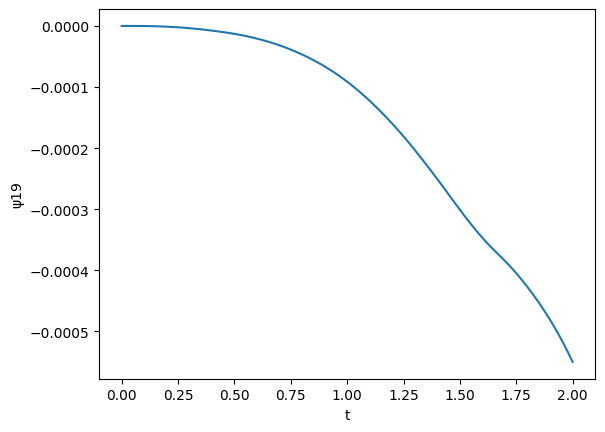

In [115]:
plt.plot(t,us.T[:,10*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('ψ{}'.format(N-1))
plt.show()

In [116]:
X010=us.T[:,0*N:1*N]

In [117]:
Y010=us.T[:,2*N:3*N]

In [118]:
Z010=us.T[:,4*N:5*N]

In [ ]:
# simulation = np.stack([X010,Y010,Z010],axis=2) 

# FPS = 5                      
# frame_duration = 1000 / FPS

# frames = []
# for t in range(simulation.shape[0]):
#     x = simulation[t,:,0]
#     y = simulation[t,:,1]
#     z = simulation[t,:,2]

#     frames.append(go.Frame(
#         data=[
#             go.Scatter3d(
#                 x=x, y=y, z=z,
#                 mode="lines+markers",
#                 marker=dict(size=5, color=list(range(12)), colorscale="Viridis"),
#                 line=dict(width=4)
#             )
#         ],
#         name=f"t={t}"
#     ))

# # First frame
# x0, y0, z0 = simulation[0,:,0], simulation[0,:,1], simulation[0,:,2]

# fig = go.Figure(
#     data=[go.Scatter3d(x=x0, y=y0, z=z0, mode="lines+markers")],
#     frames=frames
# )

# # Animation controls
# fig.update_layout(
#     title="Pipeline Simulation ",
#     scene=dict(
#         xaxis_title="X",
#         yaxis_title="Y",
#         zaxis_title="Z",
#         xaxis=dict(range=[0, 400]),
#         yaxis=dict(range=[-50, 50]),
#         zaxis=dict(range=[0, 100]),
#         aspectmode="data",
       
#     ),
#     updatemenus=[{
#         "type": "buttons",
#         "buttons": [
#             {
#                 "label": "Play",
#                 "method": "animate",
#                 "args": [None, {"frame": {"duration": frame_duration, "redraw": True}}]
#             },
#             {
#                 "label": "Pause",
#                 "method": "animate",
#                 "args": [[None], {"frame": {"duration": 0}}]
#             }
#         ]
#     }]
# )

# fig.show()